<a href="https://colab.research.google.com/github/2410010519ariefa/statistika-probabilitas-uniska/blob/main/notebooks/modul-1-eda-titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modul 1 — Statistika & Probabilitas
Praktikum: Studi Kasus Titanic Dataset

Nama: Ariefa Salsabilla Azzahra  
NPM: 2410010519  
Mata Kuliah: Statistika & Probabilitas

## 1. Setup & Import Library

In [1]:
import sys
print(sys.version)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Opsional (butuh beberapa menit): profil data otomatis
# !pip install -q ydata-profiling

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 2. Load Dataset Titanic

In [2]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Eksplorasi Awal (EDA)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


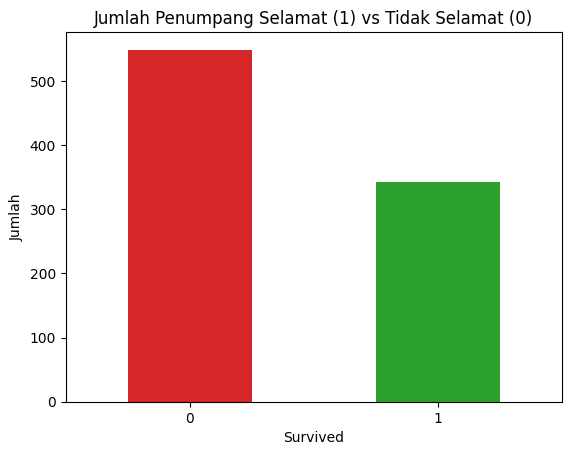

In [6]:
# Visualisasi singkat: jumlah penumpang selamat vs tidak
df["Survived"].value_counts().plot(kind="bar", color=["tab:red", "tab:green"])
plt.title("Jumlah Penumpang Selamat (1) vs Tidak Selamat (0)")
plt.xlabel("Survived")
plt.ylabel("Jumlah")
plt.xticks(rotation=0)
plt.show()

## 4. Klasifikasi Jenis Data
Tentukan skala pengukuran setiap kolom (Nominal, Ordinal, Interval, Rasio).

In [7]:
jenis_data = {
    "PassengerId": "Nominal (hanya identitas)",
    "Survived": "Nominal (label biner, target)",
    "Pclass": "Ordinal (kelas 1 > 2 > 3)",
    "Name": "Nominal",
    "Sex": "Nominal",
    "Age": "Rasio (0 tahun = tidak ada umur)",
    "SibSp": "Rasio (jumlah saudara/pasangan)",
    "Parch": "Rasio (jumlah orang tua/anak)",
    "Ticket": "Nominal",
    "Fare": "Rasio (harga tiket, 0 = gratis)",
    "Cabin": "Nominal",
    "Embarked": "Nominal (C, Q, S = pelabuhan)",
}
pd.DataFrame(list(jenis_data.items()), columns=["Kolom", "Jenis Data"])

,Kolom,Jenis Data
0,PassengerId,Nominal (hanya identitas)
1,Survived,"Nominal (label biner, target)"
2,Pclass,Ordinal (kelas 1 > 2 > 3)
3,Name,Nominal
4,Sex,Nominal
5,Age,Rasio (0 tahun = tidak ada umur)
6,SibSp,Rasio (jumlah saudara/pasangan)
7,Parch,Rasio (jumlah orang tua/anak)
8,Ticket,Nominal
9,Fare,"Rasio (harga tiket, 0 = gratis)"


## 5. Populasi vs Sampel

In [8]:
print("Jumlah baris dataset:", len(df))
print("Total penumpang Titanic (populasi sebenarnya): sekitar 2.224 orang")

# Random sampling
sampel = df.sample(n=100, random_state=42)
print("\nRata-rata umur dataset penuh :", round(df["Age"].mean(), 2))
print("Rata-rata umur sampel 100    :", round(sampel["Age"].mean(), 2))
print("Survival rate dataset penuh  :", round(df["Survived"].mean(), 3))
print("Survival rate sampel 100     :", round(sampel["Survived"].mean(), 3))

Jumlah baris dataset: 891
Total penumpang Titanic (populasi sebenarnya): sekitar 2.224 orang

Rata-rata umur dataset penuh : 29.7
Rata-rata umur sampel 100    : 29.61
Survival rate dataset penuh  : 0.384
Survival rate sampel 100     : 0.4


In [9]:
# Stratified sampling berdasarkan Pclass
from sklearn.model_selection import train_test_split

_, sampel_strat = train_test_split(df, test_size=100, stratify=df["Pclass"], random_state=42)
print("Proporsi Pclass (dataset penuh):")
print(df["Pclass"].value_counts(normalize=True).round(3))
print("\nProporsi Pclass (sampel stratified):")
print(sampel_strat["Pclass"].value_counts(normalize=True).round(3))

Proporsi Pclass (dataset penuh):
Pclass
3    0.551
1    0.242
2    0.207
Name: proportion, dtype: float64

Proporsi Pclass (sampel stratified):
Pclass
3    0.55
1    0.24
2    0.21
Name: proportion, dtype: float64


## 6. Feature Engineering Mini

In [10]:
df_fe = df.copy()

# Nominal -> One-Hot Encoding
df_fe = pd.get_dummies(df_fe, columns=["Sex", "Embarked"], dtype=int)

# Ordinal -> pemetaan urutan (Pclass sudah angka, dibuat jadi label eksplisit)
df_fe["Pclass_ord"] = df["Pclass"].map({3: 1, 2: 2, 1: 3})

df_fe[["Sex_female", "Sex_male", "Embarked_C", "Embarked_Q", "Embarked_S", "Pclass", "Pclass_ord"]].head()

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Pclass,Pclass_ord
0,0,1,0,0,1,3,1
1,1,0,1,0,0,1,3
2,1,0,0,0,1,3,1
3,1,0,0,0,1,1,3
4,0,1,0,0,1,3,1


In [11]:
from sklearn.preprocessing import MinMaxScaler

# Rasio -> MinMax Scaling (Fare) dan log untuk data skewed
df_fe["Fare_minmax"] = MinMaxScaler().fit_transform(df[["Fare"]])
df_fe["Fare_log"] = np.log1p(df["Fare"])

df_fe[["Fare", "Fare_minmax", "Fare_log"]].head()

,Fare,Fare_minmax,Fare_log
0,7.2500,0.014151,2.110213
1,71.2833,0.139136,4.280593
2,7.9250,0.015469,2.188856
3,53.1000,0.103644,3.990834
4,8.0500,0.015713,2.202765


## 7. Refleksi
Jawab kelima pertanyaan berikut dengan kata-katamu sendiri (klik dua kali sel ini untuk mengedit).

1. Mengapa statistika penting untuk model AI seperti ChatGPT, Claude, dan Gemini?

   Jawab: Model AI seperti ChatGPT, Claude, dan Gemini pada dasarnya menebak kata berikutnya berdasarkan probabilitas dari data latihnya. Jadi tanpa statistika, model AI tidak bisa bekerja dan hasilnya tidak bisa dipertanggungjawabkan

2. Mengapa Pclass termasuk data ordinal, bukan nominal?

   Jawab: Pclass termasuk ordinal karena kelasnya punya urutan, kelas 1 lebih tinggi dari kelas 2 dan 3. Tetapi jarak antar kelasnya tidak sama, jadi tidak bisa dianggap angka biasa

3. Mengapa kolom Sex tidak boleh di-encode menjadi 1 dan 2 lalu dianggap berurutan?

   Jawab: Sex termasuk data nominal yaitu hanya pembeda kategori tidak berurutan. Kalau dikodekan 1 dan 2, model akan menganggap angka mempunyai nilai dan jarak, padahal tidak ada maknanya. Oleh Karena itu dipakai one-hot encoding, jadi Sex berubah menjadi kolom Sex_female dan Sex_male yang berisi 0 atau 1

4. Apakah 891 baris Titanic ini populasi atau sampel? Jelaskan alasannya.

   Jawab: Menurut saya 891 baris itu sampel, bukan populasi. Penumpang Titanic yang sebenarnya sekitar 2.224 orang, sedangkan dataset ini hanya sebagian dan dipakai sebagai data training

5. Mengapa di era Big Data kita masih membutuhkan sampling?

   Jawab: Sampling masih dibutuhkan karena melatih model dengan jutaan data itu proses nya lambat, sedangkan sampel sudah cukup untuk uji coba